In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar

In [7]:
data_path_2024 = "/content/deli_valid (1).csv"
data_path_2025 = "/content/deli_valid_2025.csv"

In [9]:
df_2024 = pd.read_csv(data_path_2024)
df_2025 = pd.read_csv(data_path_2025)

In [13]:
df_2025.head()

,id,created_at,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall
0,442063,2025-01-01 00:00:00,23.5,80.0,21.49,95.0,512.90,33.50,0.21,NaN,NaN,NaN,NaN,NaN
1,442064,2025-01-01 00:04:00,23.5,80.0,21.58,94.0,511.93,32.16,1.02,NaN,NaN,NaN,NaN,NaN
2,442065,2025-01-01 00:06:00,23.5,80.0,21.65,94.0,511.90,48.91,0.21,NaN,NaN,NaN,NaN,NaN
3,442066,2025-01-01 00:08:00,23.5,81.0,21.64,94.0,517.89,36.18,0.21,NaN,NaN,NaN,NaN,NaN
4,442067,2025-01-01 00:10:00,23.4,80.0,21.74,93.0,519.84,36.85,0.22,NaN,NaN,NaN,NaN,NaN


In [14]:
df = pd.concat([df_2024, df_2025])
df.head(10)

,id,created_at,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall
0,211263,2024-01-01 00:00:00,26.4,79.2,NaN,17.14,1056.25,29.0,NaN,NaN,NaN,NaN,NaN,NaN
1,211264,2024-01-01 00:02:00,26.4,79.2,NaN,17.14,1056.25,29.0,NaN,NaN,NaN,NaN,NaN,NaN
2,211265,2024-01-01 00:04:00,26.4,79.2,NaN,7.41,2003.13,29.0,NaN,NaN,NaN,NaN,NaN,NaN
3,211266,2024-01-01 00:06:00,26.4,79.2,NaN,7.41,2003.13,29.0,NaN,NaN,NaN,NaN,NaN,NaN
4,211267,2024-01-01 00:08:00,26.3,79.0,NaN,17.81,1909.38,29.0,NaN,NaN,NaN,NaN,NaN,NaN
5,211268,2024-01-01 00:10:00,26.3,79.0,NaN,17.81,1909.38,29.0,NaN,NaN,NaN,NaN,NaN,NaN
6,211269,2024-01-01 00:12:00,26.4,79.2,NaN,17.08,1068.75,29.0,NaN,NaN,NaN,NaN,NaN,NaN
7,211270,2024-01-01 00:14:00,26.4,79.2,NaN,17.08,1068.75,29.0,NaN,NaN,NaN,NaN,NaN,NaN
8,211271,2024-01-01 00:16:00,26.4,79.1,NaN,2.90,2046.88,29.0,NaN,NaN,NaN,NaN,NaN,NaN
9,211272,2024-01-01 00:18:00,26.4,79.1,NaN,2.90,2046.88,29.0,NaN,NaN,NaN,NaN,NaN,NaN


### Cleaning

In [15]:
df.describe()

,id,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall
count,434232.000000,433532.000000,431144.000000,247696.000000,293064.000000,402305.000000,429655.000000,200615.000000,3924.000000,32011.0,0.0,0.0,0.0
mean,428716.060797,27.680956,73.348232,24.384310,64.875523,634.320766,48.726364,2.075530,16.801733,0.0,NaN,NaN,NaN
std,125662.049171,4.993885,17.918652,7.824636,33.833273,279.813110,26.045446,1.661721,3.272474,0.0,NaN,NaN,NaN
min,211263.000000,0.000000,0.000000,0.000000,0.000000,398.000000,0.000000,0.000000,0.000000,0.0,NaN,NaN,NaN
25%,319820.750000,23.700000,57.900000,21.810000,46.000000,501.970000,32.000000,1.150000,16.000000,0.0,NaN,NaN,NaN
50%,428378.500000,26.100000,77.600000,23.810000,75.138470,560.700000,43.550000,1.840000,16.000000,0.0,NaN,NaN,NaN
75%,537654.250000,31.800000,87.000000,29.550000,95.000000,639.000000,59.630000,2.300000,17.000000,0.0,NaN,NaN,NaN
max,646212.000000,43.600000,100.000000,42.350000,100.000000,4988.050000,277.000000,7.210000,82.000000,0.0,NaN,NaN,NaN


In [16]:
df.isnull().sum()

,0
id,0
created_at,0
temperature,700
humidity,3088
sht31_temp,186536
sht31_hum,141168
co2,31927
pm25,4577
ws,233617
wd,430308


In [17]:
df['created_at'] = pd.to_datetime(df['created_at'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 434232 entries, 0 to 204149
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           434232 non-null  int64         
 1   created_at   434232 non-null  datetime64[ns]
 2   temperature  433532 non-null  float64       
 3   humidity     431144 non-null  float64       
 4   sht31_temp   247696 non-null  float64       
 5   sht31_hum    293064 non-null  float64       
 6   co2          402305 non-null  float64       
 7   pm25         429655 non-null  float64       
 8   ws           200615 non-null  float64       
 9   wd           3924 non-null    float64       
 10  pressure     32011 non-null   float64       
 11  solar        0 non-null       float64       
 12  solar_cast   0 non-null       float64       
 13  rainfall     0 non-null       float64       
dtypes: datetime64[ns](1), float64(12), int64(1)
memory usage: 49.7 MB


In [18]:
df['year'] = df['created_at'].dt.year
df.head()

,id,created_at,temperature,humidity,sht31_temp,sht31_hum,co2,pm25,ws,wd,pressure,solar,solar_cast,rainfall,year
0,211263,2024-01-01 00:00:00,26.4,79.2,NaN,17.14,1056.25,29.0,NaN,NaN,NaN,NaN,NaN,NaN,2024
1,211264,2024-01-01 00:02:00,26.4,79.2,NaN,17.14,1056.25,29.0,NaN,NaN,NaN,NaN,NaN,NaN,2024
2,211265,2024-01-01 00:04:00,26.4,79.2,NaN,7.41,2003.13,29.0,NaN,NaN,NaN,NaN,NaN,NaN,2024
3,211266,2024-01-01 00:06:00,26.4,79.2,NaN,7.41,2003.13,29.0,NaN,NaN,NaN,NaN,NaN,NaN,2024
4,211267,2024-01-01 00:08:00,26.3,79.0,NaN,17.81,1909.38,29.0,NaN,NaN,NaN,NaN,NaN,NaN,2024


In [19]:
nan_counts_by_year = df.groupby('year')[df.columns.drop('year')].apply(lambda x: x.isnull().sum())
print(nan_counts_by_year)

      id  created_at  temperature  humidity  sht31_temp  sht31_hum    co2  \
year                                                                        
2024   0           0          220      2608       79193      33825  17728   
2025   0           0          480       480      107343     107343  14199   

      pm25      ws      wd  pressure   solar  solar_cast  rainfall  
year                                                                
2024  4575  127719  230039    198071  230082      230082    230082  
2025     2  105898  200269    204150  204150      204150    204150  


In [20]:
df = df.drop(columns=['co2', 'ws', 'wd', 'pressure', 'solar', 'solar_cast', 'rainfall'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 434232 entries, 0 to 204149
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   id           434232 non-null  int64         
 1   created_at   434232 non-null  datetime64[ns]
 2   temperature  433532 non-null  float64       
 3   humidity     431144 non-null  float64       
 4   sht31_temp   247696 non-null  float64       
 5   sht31_hum    293064 non-null  float64       
 6   pm25         429655 non-null  float64       
 7   year         434232 non-null  int32         
dtypes: datetime64[ns](1), float64(5), int32(1), int64(1)
memory usage: 28.2 MB


In [21]:
df.set_index('created_at', inplace=True, drop=True)
df.head()

,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year
created_at,,,,,,,
2024-01-01 00:00:00,211263,26.4,79.2,NaN,17.14,29.0,2024
2024-01-01 00:02:00,211264,26.4,79.2,NaN,17.14,29.0,2024
2024-01-01 00:04:00,211265,26.4,79.2,NaN,7.41,29.0,2024
2024-01-01 00:06:00,211266,26.4,79.2,NaN,7.41,29.0,2024
2024-01-01 00:08:00,211267,26.3,79.0,NaN,17.81,29.0,2024


In [22]:
hourly_counts = df.resample('h').count()
hourly_means = df.resample('h').mean()

# Apply the condition: set mean to NaN if count < 23
for col in hourly_means.columns:
    hourly_means.loc[hourly_counts[col] < 23, col] = np.nan

# Round numerical columns to 2 decimal places (excluding 'year' which should be integer)
for col in hourly_means.columns:
    if pd.api.types.is_numeric_dtype(hourly_means[col]) and col != 'year':
        hourly_means[col] = hourly_means[col].round(2)

# Convert 'year' to integer, handling potential NaN values
if 'year' in hourly_means.columns:
    hourly_means['year'] = hourly_means['year'].apply(lambda x: int(x) if pd.notna(x) else x)

# Replace the 'id' column with a sequential series starting from 1
hourly_means['id'] = range(1, len(hourly_means) + 1)

# Reorder columns to ensure 'id' is the first column
current_cols = hourly_means.columns.tolist()
if 'id' in current_cols:
    current_cols.remove('id')
hourly_means = hourly_means[['id'] + current_cols]

# Display the first and last 5 rows
hourly_means.head(10)

,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year
created_at,,,,,,,
2024-01-01 00:00:00,1,26.38,78.93,NaN,12.50,29.00,2024.0
2024-01-01 01:00:00,2,26.31,78.48,NaN,10.69,87.20,2024.0
2024-01-01 02:00:00,3,26.21,77.97,NaN,9.50,145.27,2024.0
2024-01-01 03:00:00,4,25.96,77.64,NaN,9.38,98.80,2024.0
2024-01-01 04:00:00,5,25.85,77.90,NaN,9.94,101.93,2024.0
2024-01-01 05:00:00,6,25.55,78.10,NaN,9.07,92.13,2024.0
2024-01-01 06:00:00,7,27.28,75.18,NaN,8.71,116.07,2024.0
2024-01-01 07:00:00,8,30.01,66.98,NaN,9.32,138.24,2024.0
2024-01-01 08:00:00,9,36.53,47.40,NaN,7.56,98.40,2024.0


In [23]:
hourly_means['month'] = hourly_means.index.month

df_2024_hourly = hourly_means[hourly_means['year'] == 2024.0]
df_2025_hourly = hourly_means[hourly_means['year'] == 2025.0]

df_combined_hourly = pd.concat([df_2024_hourly, df_2025_hourly])

df_combined_hourly.head()

,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2024-01-01 00:00:00,1,26.38,78.93,NaN,12.50,29.00,2024.0,1
2024-01-01 01:00:00,2,26.31,78.48,NaN,10.69,87.20,2024.0,1
2024-01-01 02:00:00,3,26.21,77.97,NaN,9.50,145.27,2024.0,1
2024-01-01 03:00:00,4,25.96,77.64,NaN,9.38,98.80,2024.0,1
2024-01-01 04:00:00,5,25.85,77.90,NaN,9.94,101.93,2024.0,1


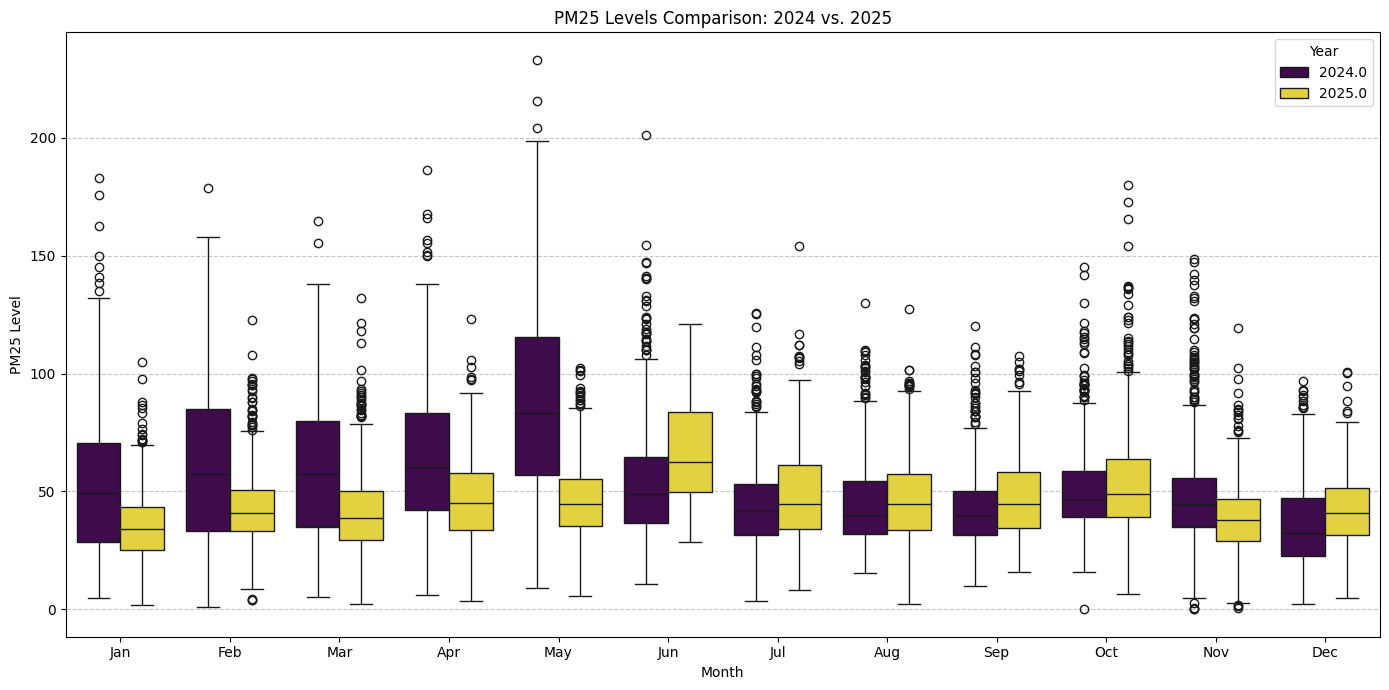

In [24]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='month', y='pm25', hue='year', data=df_combined_hourly, palette='viridis')
plt.title('PM25 Levels Comparison: 2024 vs. 2025')
plt.xlabel('Month')
plt.ylabel('PM25 Level')
plt.xticks(ticks=range(12), labels=[calendar.month_abbr[i+1] for i in range(12)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

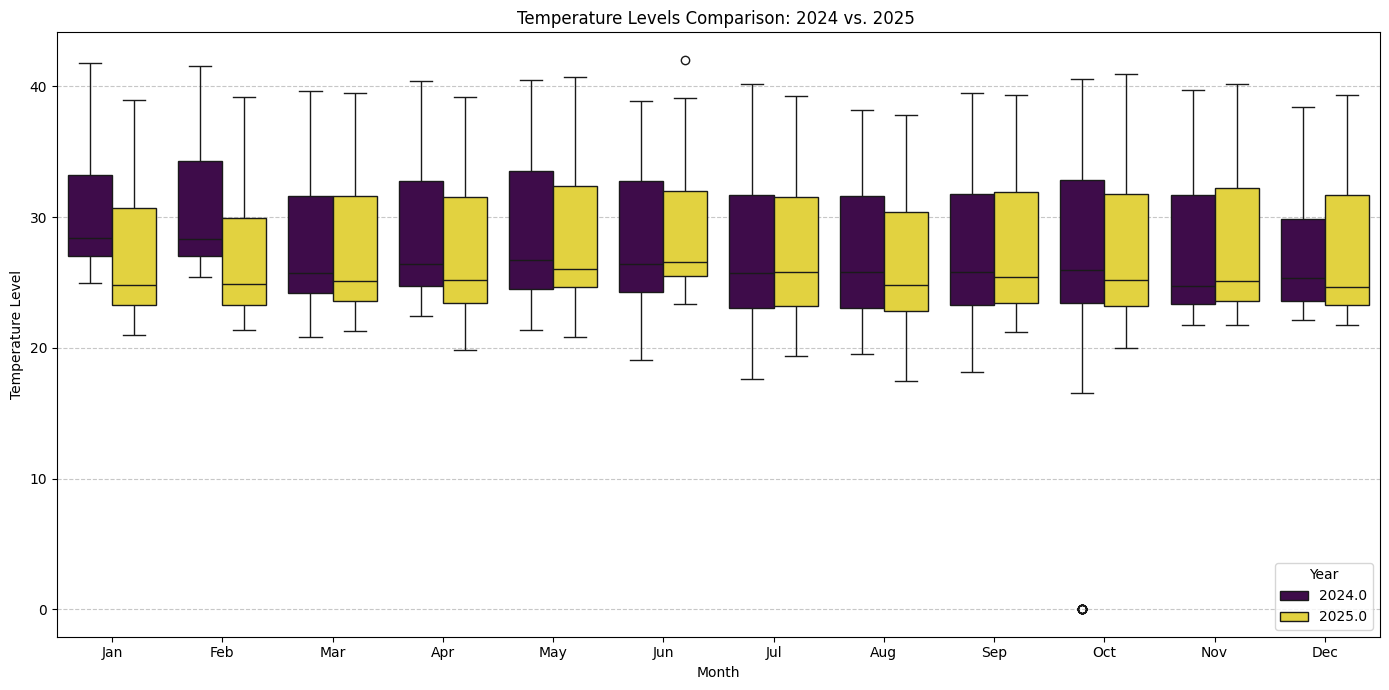

In [25]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='month', y='temperature', hue='year', data=df_combined_hourly, palette='viridis')
plt.title('Temperature Levels Comparison: 2024 vs. 2025 ')
plt.xlabel('Month')
plt.ylabel('Temperature Level')
plt.xticks(ticks=range(12), labels=[calendar.month_abbr[i+1] for i in range(12)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

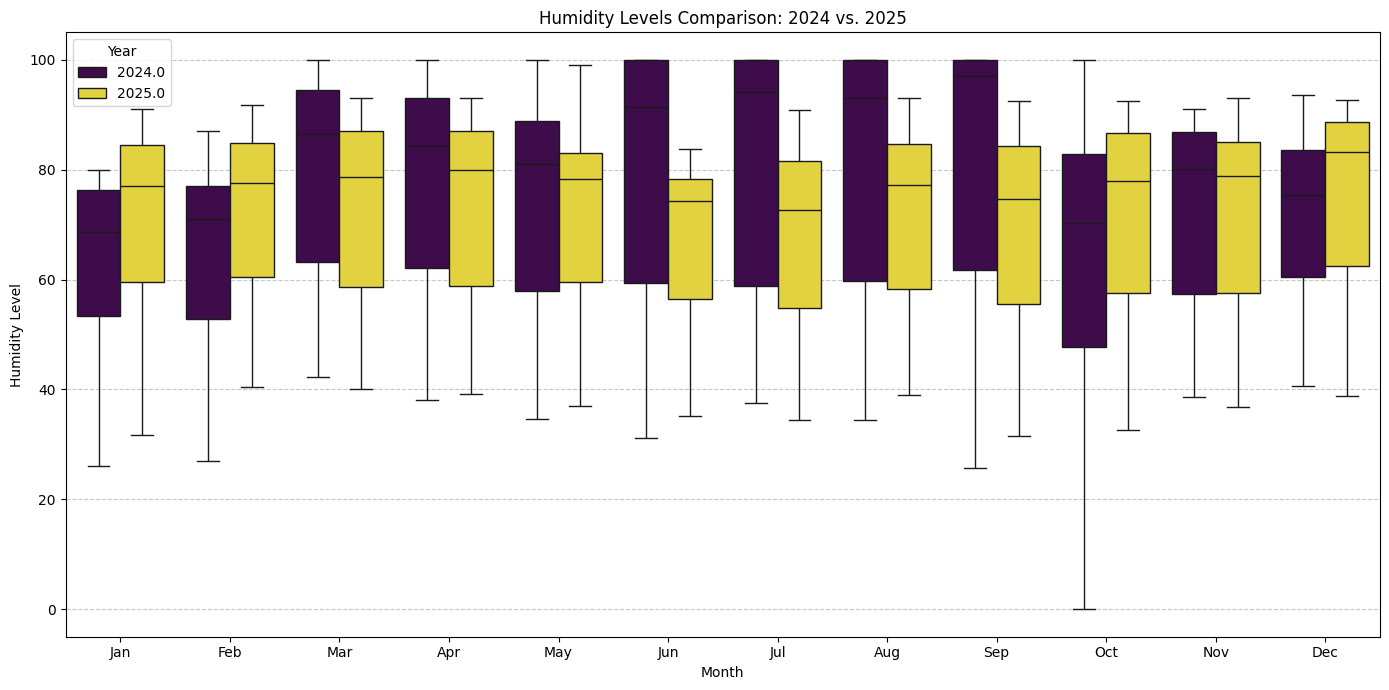

In [26]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='month', y='humidity', hue='year', data=df_combined_hourly, palette='viridis')
plt.title('Humidity Levels Comparison: 2024 vs. 2025')
plt.xlabel('Month')
plt.ylabel('Humidity Level')
plt.xticks(ticks=range(12), labels=[calendar.month_abbr[i+1] for i in range(12)])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()
plt.show()

### Cleaning Outlier

In [27]:
import numpy as np

# Define target columns
target_columns = ['pm25', 'temperature', 'humidity']

# 1. Function to remove outliers using IQR
def remove_outliers(group):
    for col in target_columns:
        if col in group.columns and not group[col].isnull().all():
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            # Set outliers to NaN
            group.loc[(group[col] < lower_bound) | (group[col] > upper_bound), col] = np.nan
    return group

# 2. Apply cleaning multiple times (5 passes) to reach absolute stability
for i in range(6):
    df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)

print("Data cleaning (5 passes) completed.")

# 3. Final Verification for visual consistency
sample_year, sample_month = 2024.0, 1
cleaned_sample_group = df_combined_hourly[(df_combined_hourly['year'] == sample_year) & (df_combined_hourly['month'] == sample_month)]

print(f"\n--- Final Outlier Check (Year: {int(sample_year)}, Month: {sample_month}) ---")
for col in target_columns:
    if not cleaned_sample_group[col].isnull().all():
        Q1, Q3 = cleaned_sample_group[col].quantile(0.25), cleaned_sample_group[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = cleaned_sample_group[(cleaned_sample_group[col] < lower) | (cleaned_sample_group[col] > upper)]
        print(f"  {col}: {len(outliers)} outliers remaining in sample group.")

/tmp/ipykernel_2357/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_2357/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_2357/132759

Data cleaning (5 passes) completed.

--- Final Outlier Check (Year: 2024, Month: 1) ---
  pm25: 0 outliers remaining in sample group.
  temperature: 0 outliers remaining in sample group.
  humidity: 0 outliers remaining in sample group.


/tmp/ipykernel_2357/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)
/tmp/ipykernel_2357/1327597873.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_combined_hourly = df_combined_hourly.groupby(['year', 'month'], group_keys=False).apply(remove_outliers)


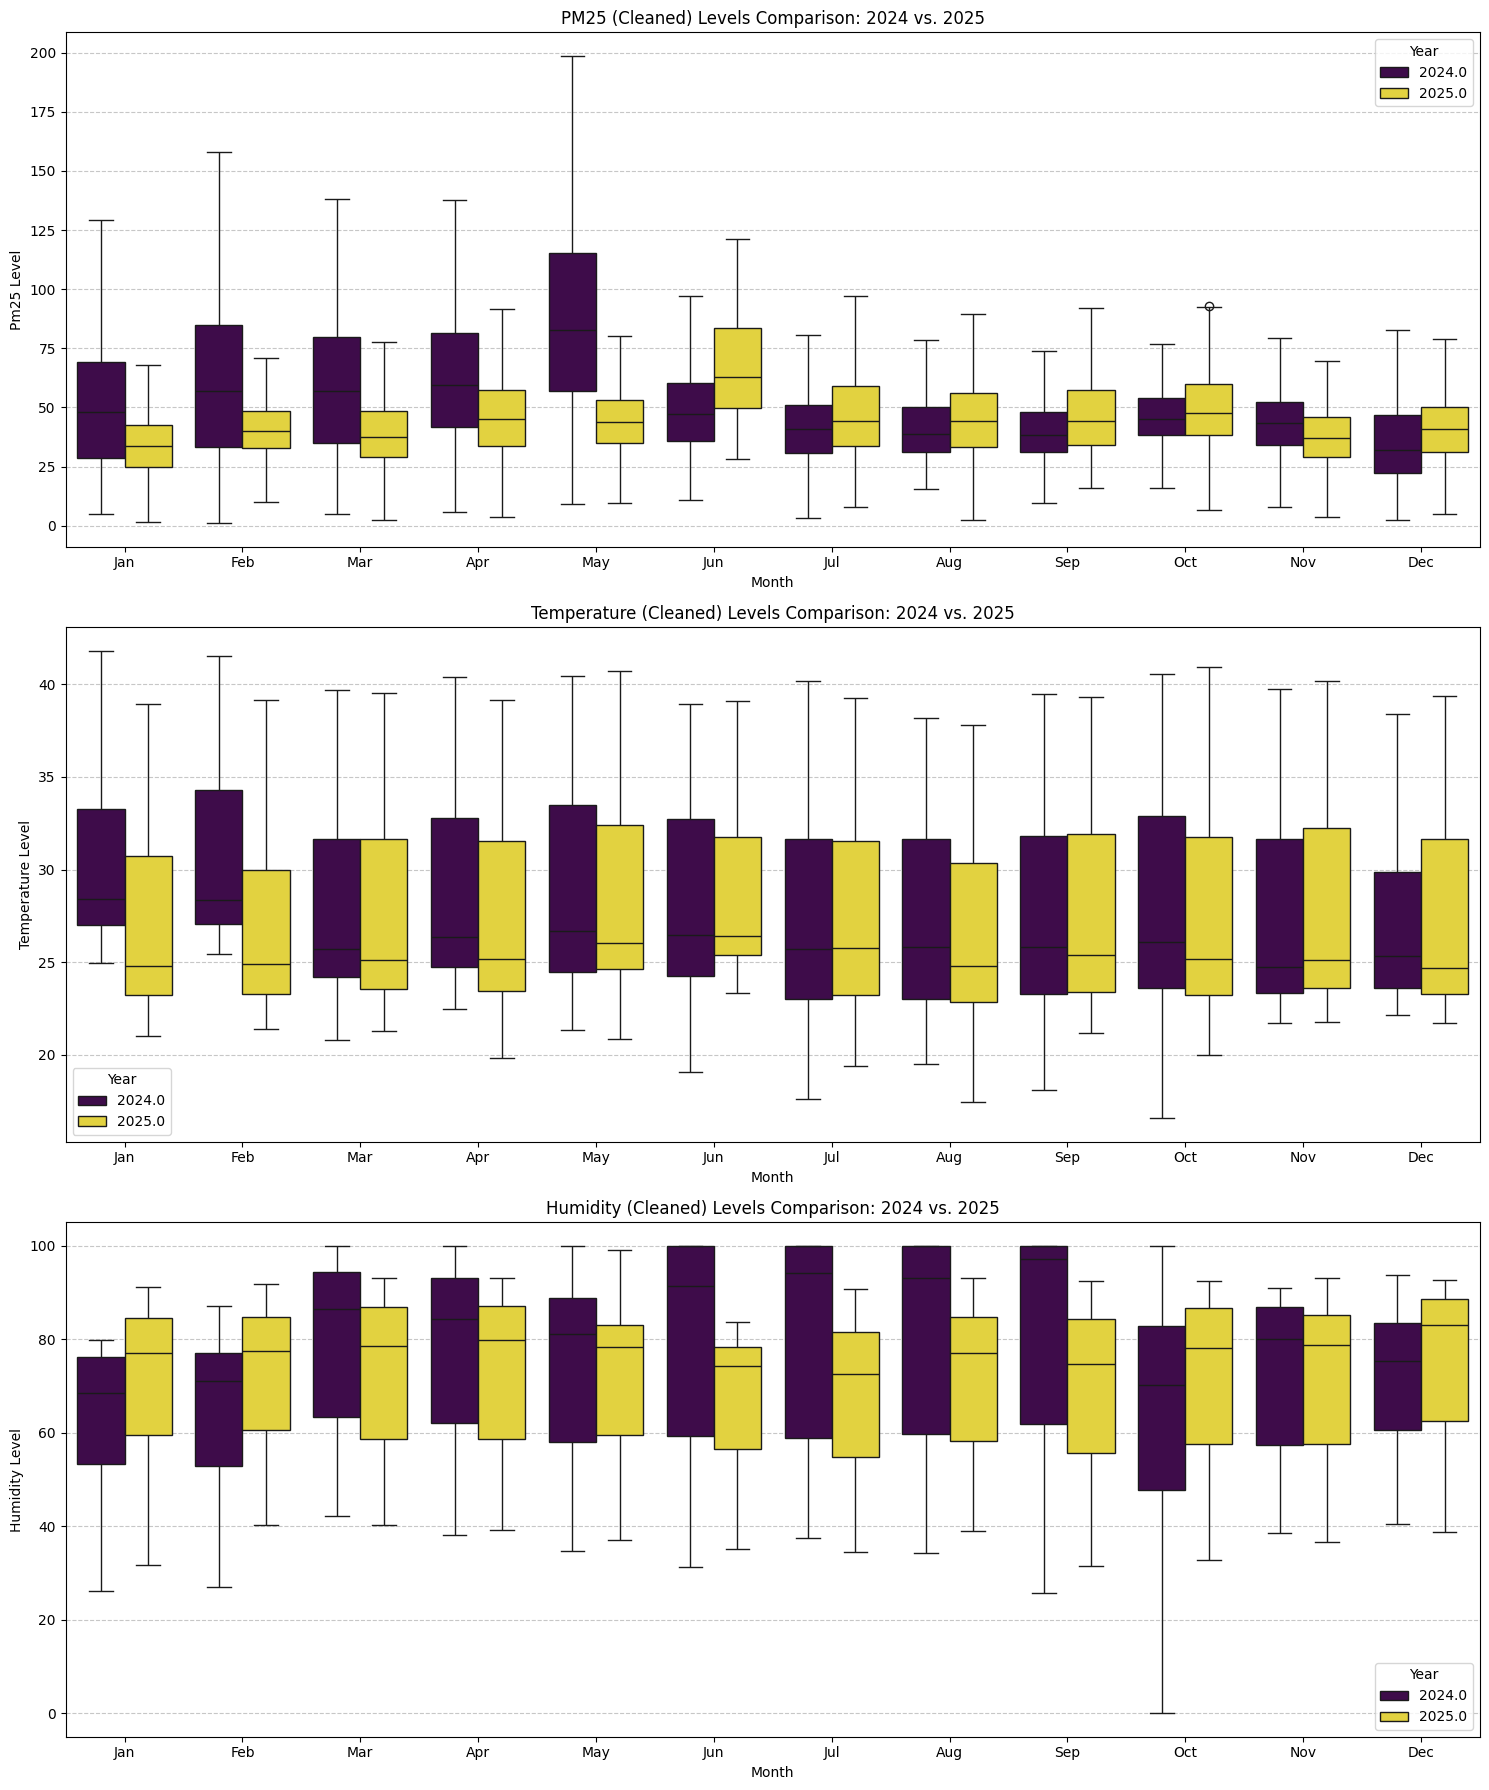

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18))
target_cols = ['pm25', 'temperature', 'humidity']
col_titles = ['PM25 (Cleaned)', 'Temperature (Cleaned)', 'Humidity (Cleaned)']

for i, col in enumerate(target_cols):
    sns.boxplot(ax=axes[i], x='month', y=col, hue='year', data=df_combined_hourly, palette='viridis')
    axes[i].set_title(f'{col_titles[i]} Levels Comparison: 2024 vs. 2025')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(f'{col.capitalize()} Level')
    axes[i].set_xticks(range(12))
    axes[i].set_xticklabels([calendar.month_abbr[m+1] for m in range(12)])
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].legend(title='Year')

plt.tight_layout()
plt.show()

In [29]:
print("Head of cleaned df_combined_hourly:")
display(df_combined_hourly.head())

print("\nTail of cleaned df_combined_hourly:")
display(df_combined_hourly.tail())

Head of cleaned df_combined_hourly:


,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2024-01-01 00:00:00,1,26.38,78.93,NaN,12.50,29.00,2024.0,1
2024-01-01 01:00:00,2,26.31,78.48,NaN,10.69,87.20,2024.0,1
2024-01-01 02:00:00,3,26.21,77.97,NaN,9.50,NaN,2024.0,1
2024-01-01 03:00:00,4,25.96,77.64,NaN,9.38,98.80,2024.0,1
2024-01-01 04:00:00,5,25.85,77.90,NaN,9.94,101.93,2024.0,1



Tail of cleaned df_combined_hourly:


,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2025-12-30 19:00:00,17516,25.21,82.62,0.0,0.0,38.42,2025.0,12
2025-12-30 20:00:00,17517,25.02,84.15,0.0,0.0,41.04,2025.0,12
2025-12-30 21:00:00,17518,24.96,84.73,0.0,0.0,52.99,2025.0,12
2025-12-30 22:00:00,17519,24.72,84.39,0.0,0.0,53.26,2025.0,12
2025-12-30 23:00:00,17520,24.38,84.07,0.0,0.0,40.98,2025.0,12


In [30]:
target_columns = ['pm25', 'temperature', 'humidity']
null_counts_after_cleaning = df_combined_hourly[target_columns].isnull().sum()

print("Final Null Counts in Target Columns (After 5-pass IQR Cleaning):")
print(null_counts_after_cleaning)

Final Null Counts in Target Columns (After 5-pass IQR Cleaning):
pm25           717
temperature     25
humidity        94
dtype: int64


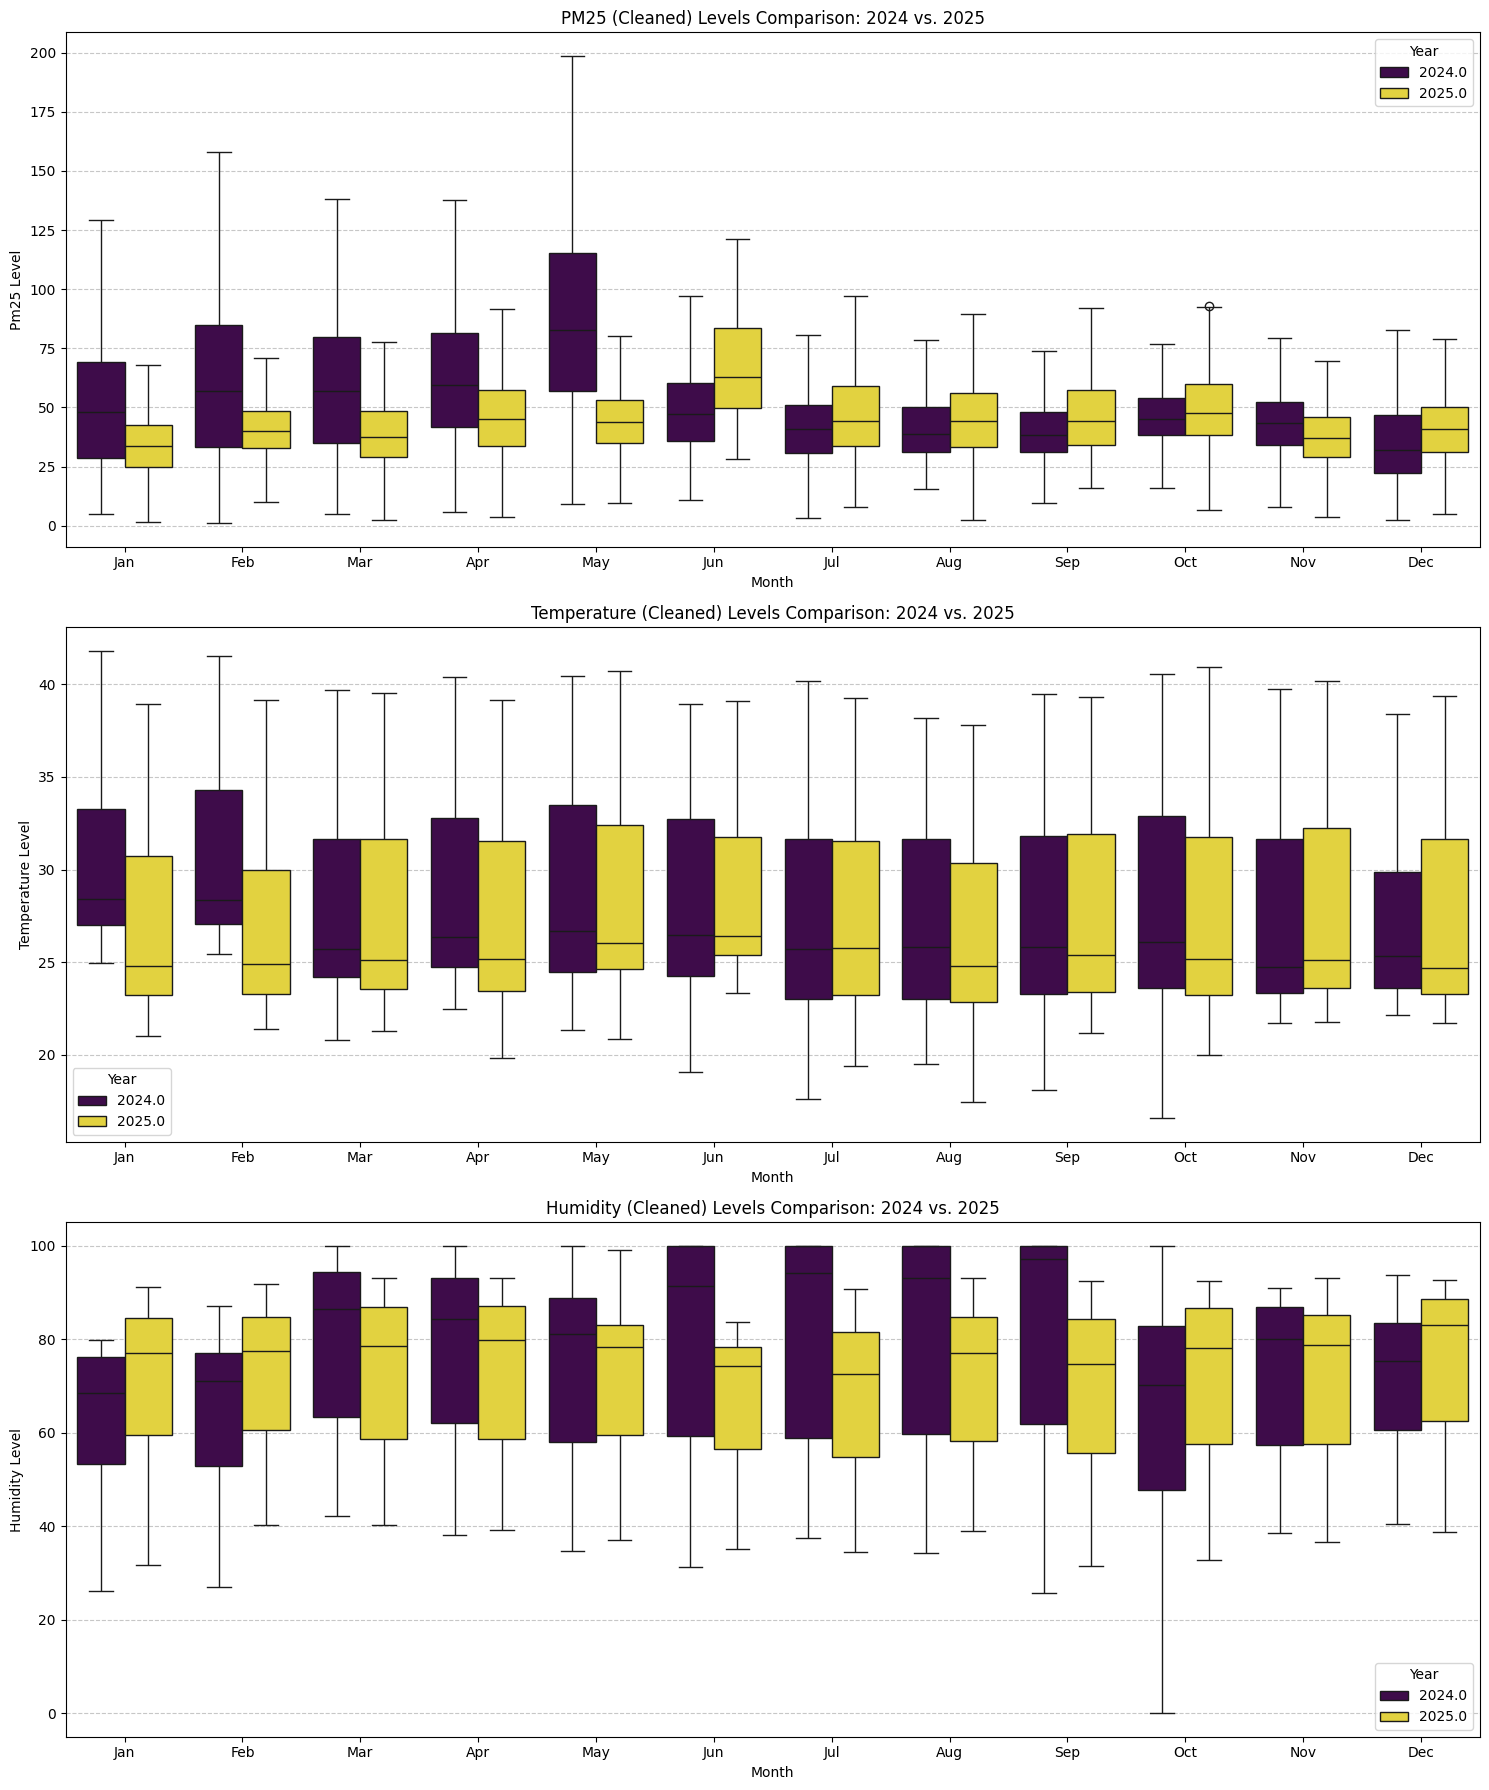

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18))
target_cols = ['pm25', 'temperature', 'humidity']
col_titles = ['PM25 (Cleaned)', 'Temperature (Cleaned)', 'Humidity (Cleaned)']

for i, col in enumerate(target_cols):
    sns.boxplot(ax=axes[i], x='month', y=col, hue='year', data=df_combined_hourly, palette='viridis')
    axes[i].set_title(f'{col_titles[i]} Levels Comparison: 2024 vs. 2025')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(f'{col.capitalize()} Level')
    axes[i].set_xticks(range(12))
    axes[i].set_xticklabels([calendar.month_abbr[m+1] for m in range(12)])
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].legend(title='Year')

plt.tight_layout()
plt.show()

In [33]:
# Membuat dataset final untuk pelatihan model
data_training_deli = df_combined_hourly.copy()

# Menampilkan informasi dataset baru
print("Dataset 'data_training_deli' berhasil dibuat.")
print(f"Jumlah baris: {data_training_deli.shape[0]}")
print(f"Jumlah kolom: {data_training_deli.shape[1]}")
display(data_training_deli.head(5))

Dataset 'data_training_deli' berhasil dibuat.
Jumlah baris: 14384
Jumlah kolom: 8


,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
created_at,,,,,,,,
2024-01-01 00:00:00,1,26.38,78.93,NaN,12.50,29.00,2024.0,1
2024-01-01 01:00:00,2,26.31,78.48,NaN,10.69,87.20,2024.0,1
2024-01-01 02:00:00,3,26.21,77.97,NaN,9.50,NaN,2024.0,1
2024-01-01 03:00:00,4,25.96,77.64,NaN,9.38,98.80,2024.0,1
2024-01-01 04:00:00,5,25.85,77.90,NaN,9.94,101.93,2024.0,1


In [34]:
# Menyimpan dataset final ke file CSV
file_name = "data_training_deli.csv"
data_training_deli.to_csv(file_name, index=True)

print(f"Dataset berhasil disimpan dengan nama: {file_name}")

Dataset berhasil disimpan dengan nama: data_training_deli.csv
